In [49]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize

In [ ]:
det_frpm_crit_1404 = [210,252,294]
det_from_crit_1404 = np.array(det_frpm_crit_1404)
DW_exp_speed_1404 = [8.4,6.3,4.8]
DW_exp_speed_1404 = np.array(DW_exp_speed_1404)
fluct_decay_1404 = [4.,12.,13.0]
fluct_decay_1404 = np.array(fluct_decay_1404)
kn_1404 = 820 #Hz
det_norm_1404 = det_from_crit_1404/kn_1404
det_from_crit_1504 = [147,230]
det_from_crit_1504 = np.array(det_from_crit_1504)
DW_exp_speed_1504 = [21,7.5]
DW_exp_speed_1504 = np.array(DW_exp_speed_1504)
fluct_decay_1504 = [20.,3.5]
fluct_decay_1504 = np.array(fluct_decay_1504)
kn_1504 = 715 #Hz
det_norm_1504 = det_from_crit_1504/kn_1504

det_from_crit_1504_1 = [180,295,252]
det_from_crit_1504_1 = np.array(det_from_crit_1504_1)
DW_exp_speed_1504_1 = [15.2,7.6,9.9]
DW_exp_speed_1504_1 = np.array(DW_exp_speed_1504_1)
fluct_decay_1504_1 = [0.,0.]
fluct_decay_1504_1 = np.array(fluct_decay_1504_1)
kn_1504_1 = 735 #Hz
det_norm_1504_1 = det_from_crit_1504_1/kn_1504_1    

det_from_crit_all = np.concatenate((det_from_crit_1404, det_from_crit_1504, det_from_crit_1504_1))
DW_exp_speed_all = np.concatenate((DW_exp_speed_1404, DW_exp_speed_1504, DW_exp_speed_1504_1))
fluct_decay_all = np.concatenate((fluct_decay_1404, fluct_decay_1504, fluct_decay_1504_1))
det_norm_all = np.concatenate((det_norm_1404, det_norm_1504, det_norm_1504_1))


In [51]:
def fit_DW_speed(det_norm, alpha,A,B):
    speed = (np.abs(det_norm-0.5))**alpha*A + B
    
    return speed

In [52]:
fit_all_results = scipy.optimize.curve_fit(fit_DW_speed, det_norm_all, DW_exp_speed_all, p0=[1,10,0])
alpha_fit, A_fit, B_fit = fit_all_results[0]
print(f'Fitted alpha: {alpha_fit:.3f}, A: {A_fit:.3f}, B: {B_fit:.3f}')

Fitted alpha: 6.031, A: 23408.751, B: 6.755


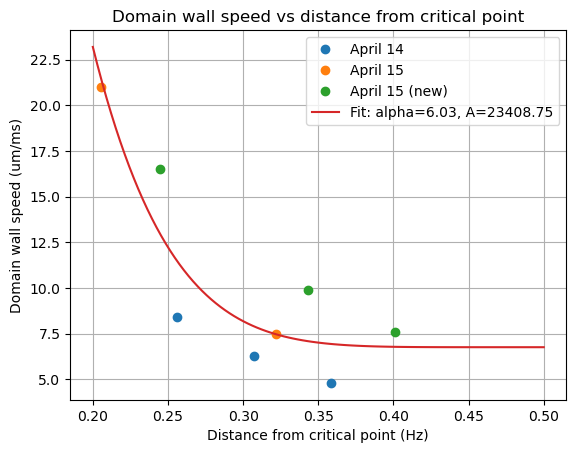

In [53]:
plt.figure()
plt.plot(det_norm_1404,DW_exp_speed_1404,'o', label='April 14')
plt.plot(det_norm_1504,DW_exp_speed_1504,'o', label='April 15')
plt.plot(det_norm_1504_1,DW_exp_speed_1504_1,'o', label='April 15 (new)')
det_norm_all_for_fit = np.linspace(0.2,0.5,100)
plt.plot(det_norm_all_for_fit, fit_DW_speed(det_norm_all_for_fit, *fit_all_results[0]), '-', label=f'Fit: alpha={alpha_fit:.2f}, A={A_fit:.2f}')
plt.xlabel('Distance from critical point (Hz)')
plt.ylabel('Domain wall speed (um/ms)')
plt.title('Domain wall speed vs distance from critical point')
plt.grid()
plt.legend()
plt.show()

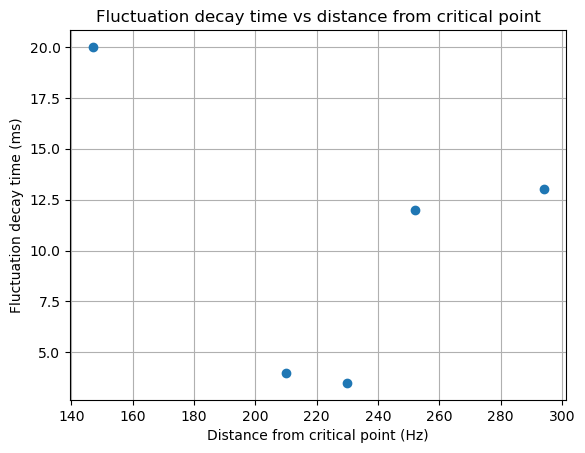

In [54]:
plt.figure()
plt.plot(det_from_crit,fluct_decay,'o')
plt.xlabel('Distance from critical point (Hz)')
plt.ylabel('Fluctuation decay time (ms)')
plt.title('Fluctuation decay time vs distance from critical point')
plt.grid()
plt.show()